# Downsampling Demo

`resample.downsample` simulates **irregular sub-sampling**: it randomly selects
a subset of points from the original series, keeping their exact values at the
selected times.

### How this differs from reframing the time axis

| Operation | What it does | When to use |
|---|---|---|
| **`downsample`** (this notebook) | Randomly *skips* points — kept values are exact | Simulate a sparse proxy record from dense model output |
| **`interp` / `common_time`** | Interpolates onto a new uniform grid — *invents* values | Clean up adaptive-timestep solver output; align two series |


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pyleoclim as pyleo
from paleobeasts.utils.resample import downsample


{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [20]:
series = pyleo.utils.load_dataset('SOI').interp()
print(f'n={len(series.time)}  dt={series.time[1]-series.time[0]:.3f} yr  '
      f'span={series.time[0]:.1f}–{series.time[-1]:.1f} yr')


n=1909  dt=0.083 yr  span=1866.0–2025.0 yr
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


### Original series and resolution

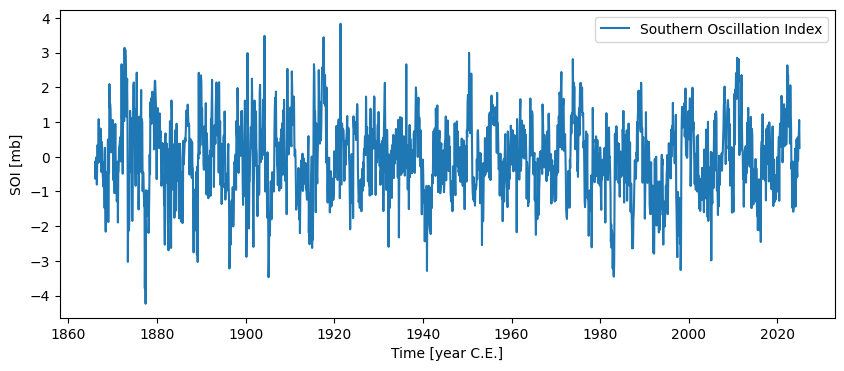

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [21]:
fig, ax = series.plot()

(<Figure size 1100x800 with 2 Axes>,
 {'res': <Axes: xlabel='Time [year C.E.]', ylabel='resolution [year C.E.]'>,
  'res_hist': <Axes: xlabel='Counts'>})

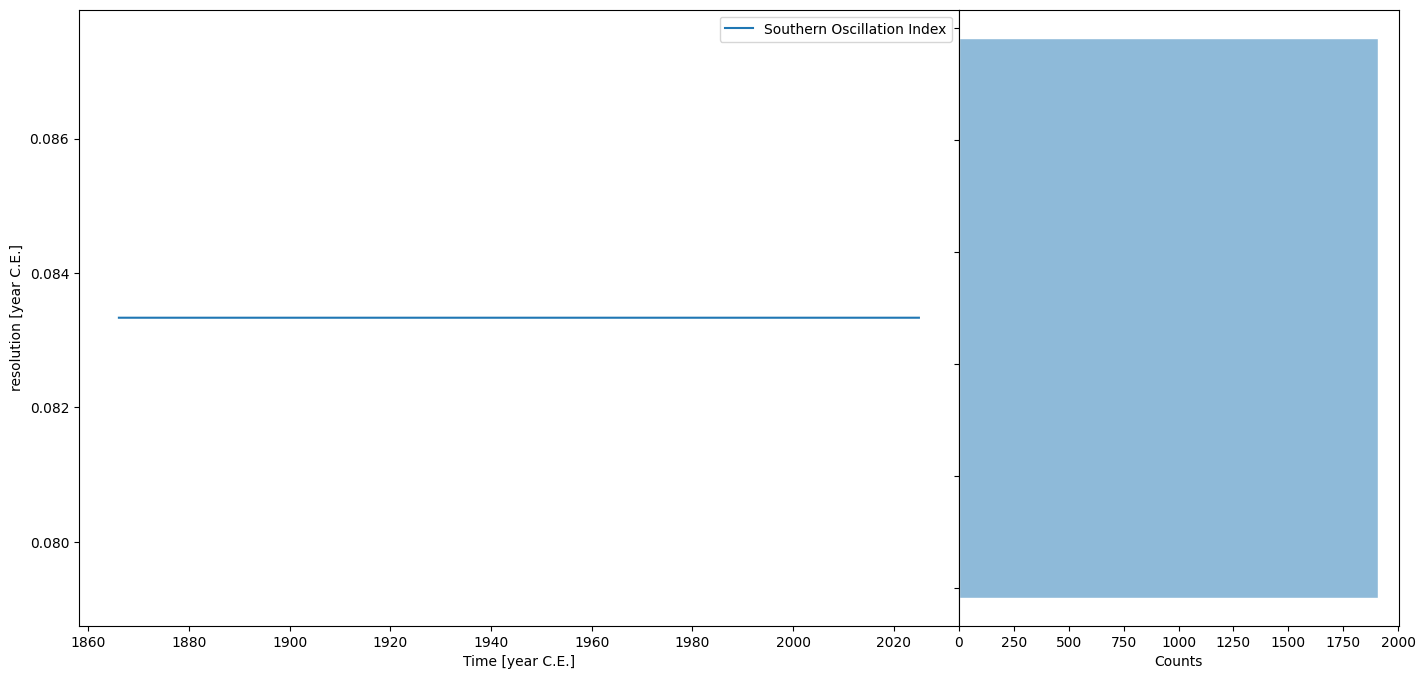

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [22]:
series.resolution().dashboard()

## Exponential

`method='exponential'`, `param=[scale]`

Index gaps ~ Exponential(scale).  Scale = mean gap size.  Heavy right tail:
most gaps are small, occasional large ones — like bioturbated marine records.


In [23]:
ds_exp = downsample(series, method='exponential', param=[2], seed=42)

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


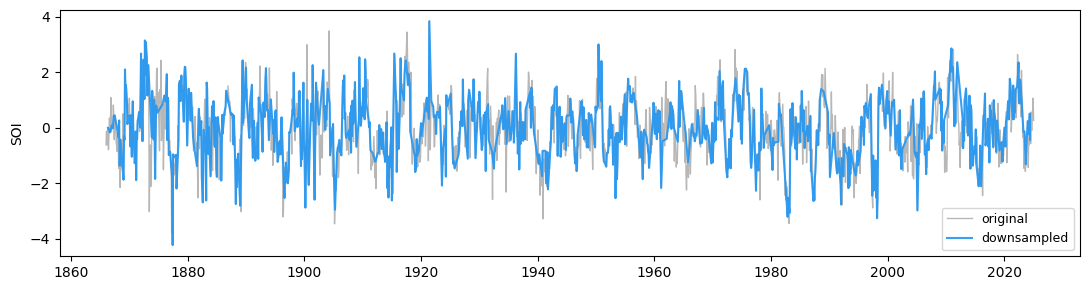

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [24]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(series.time, series.value,
        color='#888888', lw=1.0, alpha=0.6, label='original')
ax.plot(ds_exp.time, ds_exp.value,
        color='#2196F3', lw=1.5, alpha=0.9, label='downsampled')
ax.set_ylabel('SOI'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


**Figure.** The sparse record (blue) keeps exact values at selected indices.
Compare coverage and gap structure to the original (gray).


(<Figure size 1100x800 with 2 Axes>,
 {'res': <Axes: xlabel='Time [year C.E.]', ylabel='resolution [year C.E.]'>,
  'res_hist': <Axes: xlabel='Counts'>})

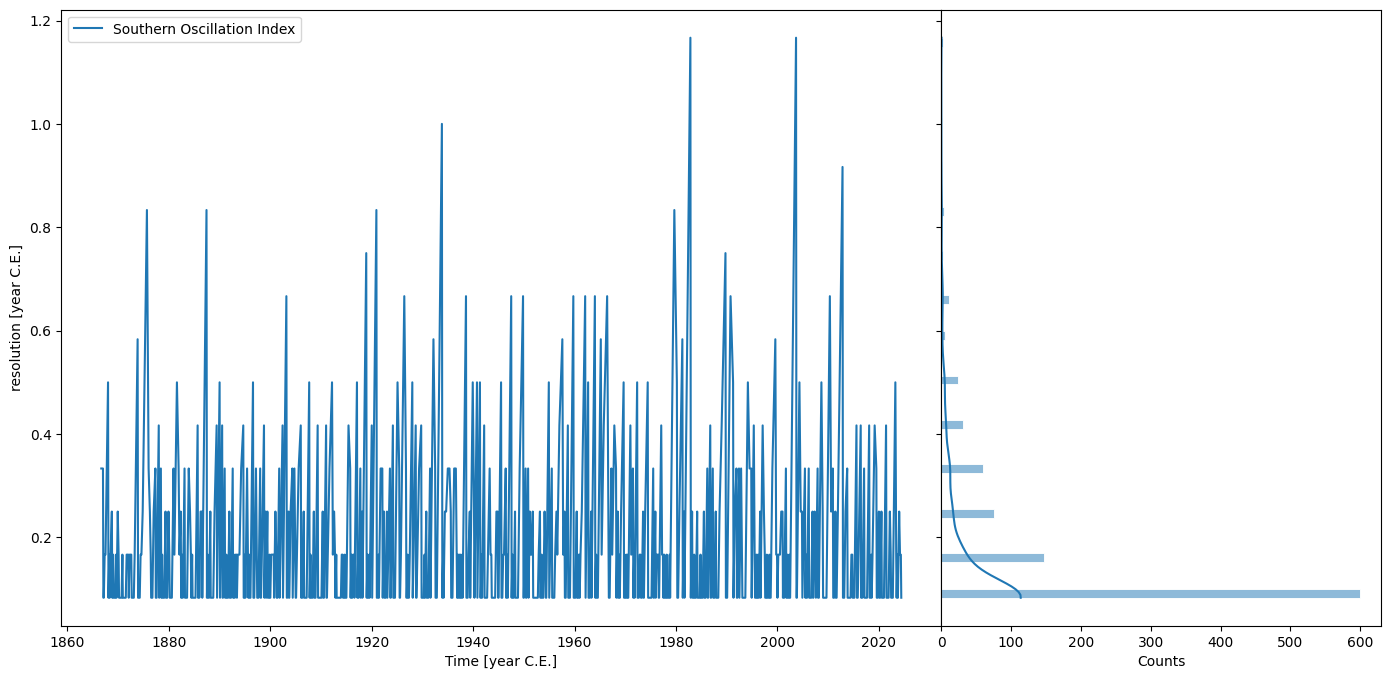

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [25]:
ds_exp.resolution().dashboard()

## Poisson

`method='poisson'`, `param=[rate]`

Gaps ~ Poisson(rate) + 1.  More symmetric around the mean — fewer extreme
long gaps than Exponential.


In [26]:
ds_poi = downsample(series, method='poisson', param=[3], seed=42)

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


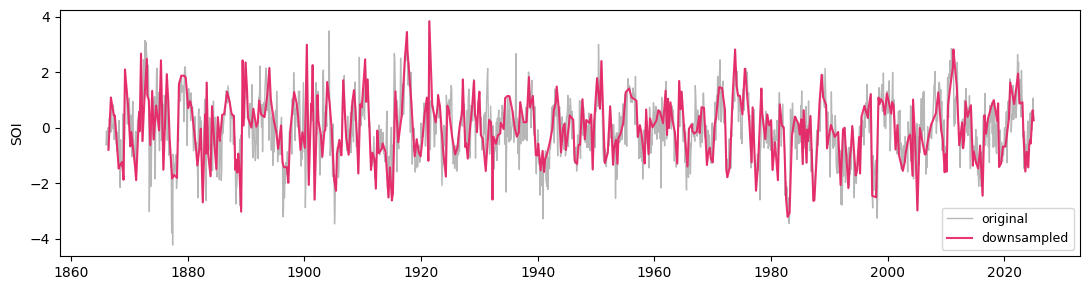

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [27]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(series.time, series.value,
        color='#888888', lw=1.0, alpha=0.6, label='original')
ax.plot(ds_poi.time, ds_poi.value,
        color='#E91E63', lw=1.5, alpha=0.9, label='downsampled')
ax.set_ylabel('SOI'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


**Figure.** Tighter gap distribution: coverage is more uniform than Exponential,
fewer long stretches without a sample.


(<Figure size 1100x800 with 2 Axes>,
 {'res': <Axes: xlabel='Time [year C.E.]', ylabel='resolution [year C.E.]'>,
  'res_hist': <Axes: xlabel='Counts'>})

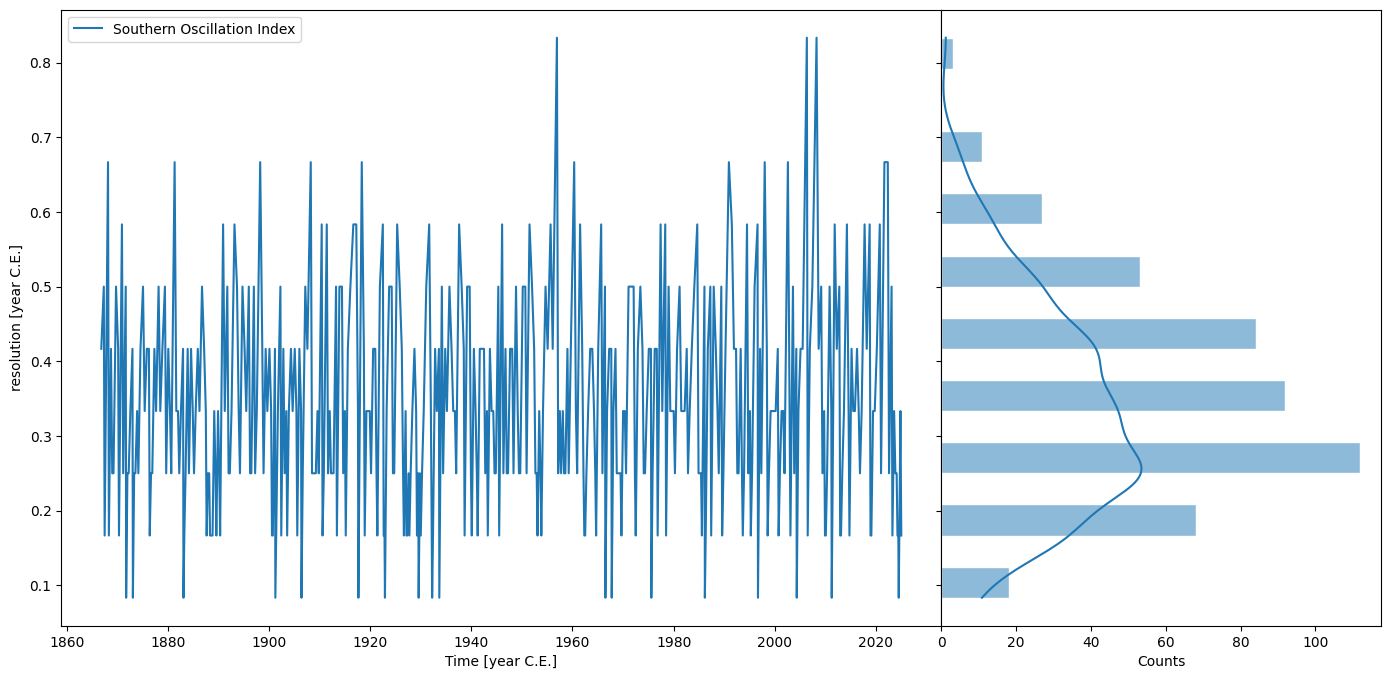

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [28]:
ds_poi.resolution().dashboard()

## Pareto

`method='pareto'`, `param=[shape, scale]`

Gaps ~ (Pareto(shape) + 1) × scale.  Power-law tail: small `shape` → very
heavy tail with occasional extremely long hiatuses.  Mimics patchy carbonate
preservation.


In [29]:
ds_par = downsample(series, method='pareto', param=[2, 1], seed=42)

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


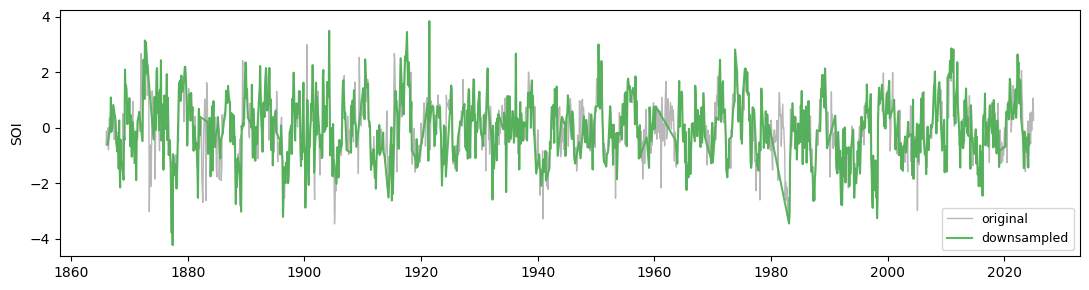

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [30]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(series.time, series.value,
        color='#888888', lw=1.0, alpha=0.6, label='original')
ax.plot(ds_par.time, ds_par.value,
        color='#4CAF50', lw=1.5, alpha=0.9, label='downsampled')
ax.set_ylabel('SOI'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


**Figure.** Rare but very long gaps dominate the resolution dashboard — the
heavy tail means the record can go silent for extended periods.


(<Figure size 1100x800 with 2 Axes>,
 {'res': <Axes: xlabel='Time [year C.E.]', ylabel='resolution [year C.E.]'>,
  'res_hist': <Axes: xlabel='Counts'>})

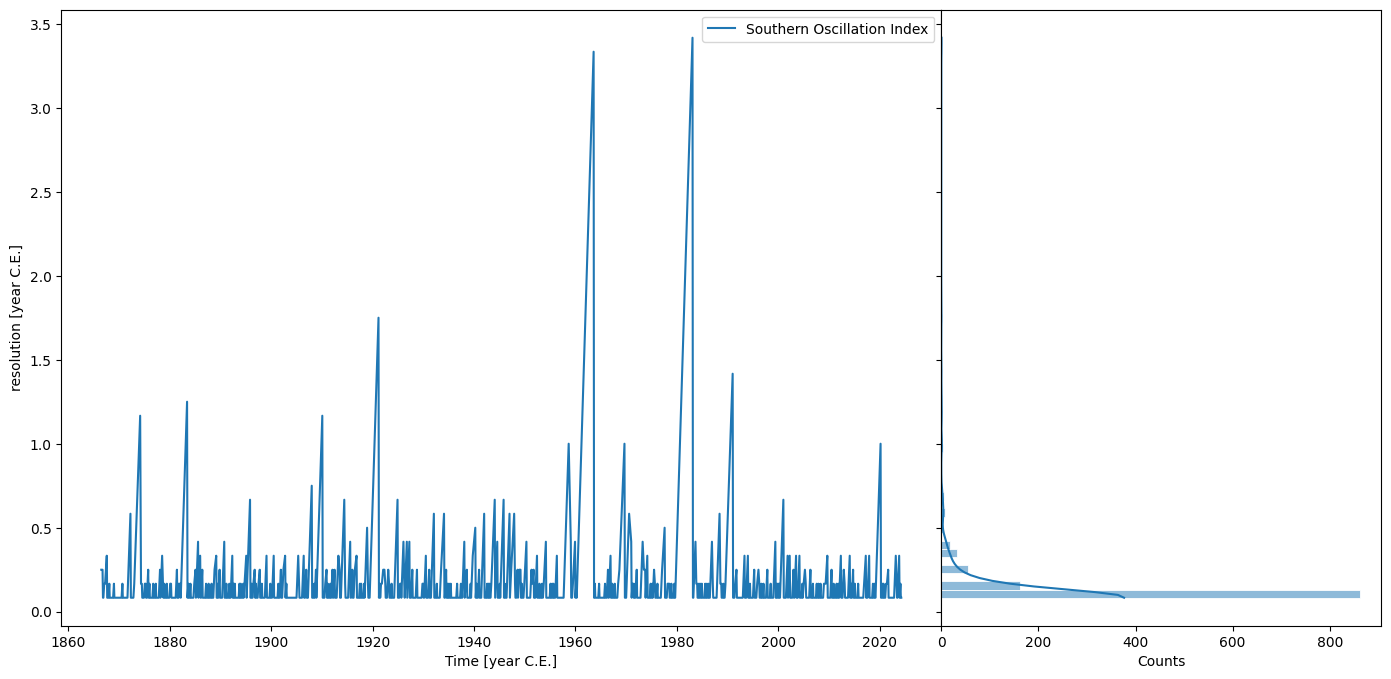

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [31]:
ds_par.resolution().dashboard()

## Random choice

`method='random_choice'`, `param=[[values], [probabilities]]`

Gaps drawn from a discrete distribution.  Use when you know the sampling
process — e.g. annual cores with occasional multi-year losses.


In [32]:
ds_rc = downsample(series, method='random_choice',
                   param=[[1, 5, 20], [0.80, 0.15, 0.05]], seed=42)


{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


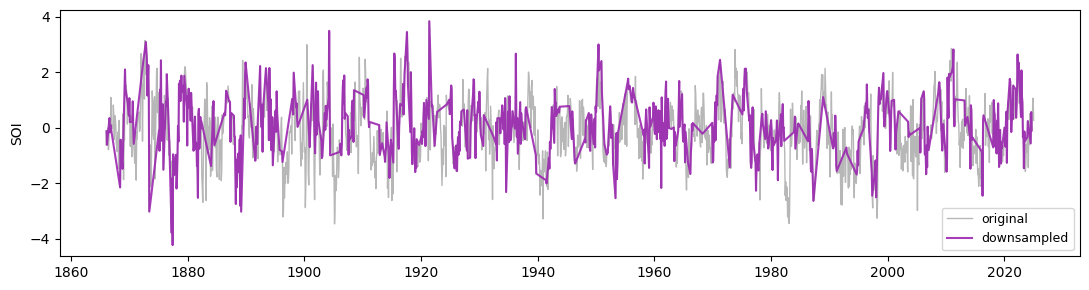

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [33]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(series.time, series.value,
        color='#888888', lw=1.0, alpha=0.6, label='original')
ax.plot(ds_rc.time, ds_rc.value,
        color='#9C27B0', lw=1.5, alpha=0.9, label='downsampled')
ax.set_ylabel('SOI'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


**Figure.** Three distinct gap sizes visible in the resolution dashboard,
at the specified probabilities (80 % × 1, 15 % × 5, 5 % × 20).


(<Figure size 1100x800 with 2 Axes>,
 {'res': <Axes: xlabel='Time [year C.E.]', ylabel='resolution [year C.E.]'>,
  'res_hist': <Axes: xlabel='Counts'>})

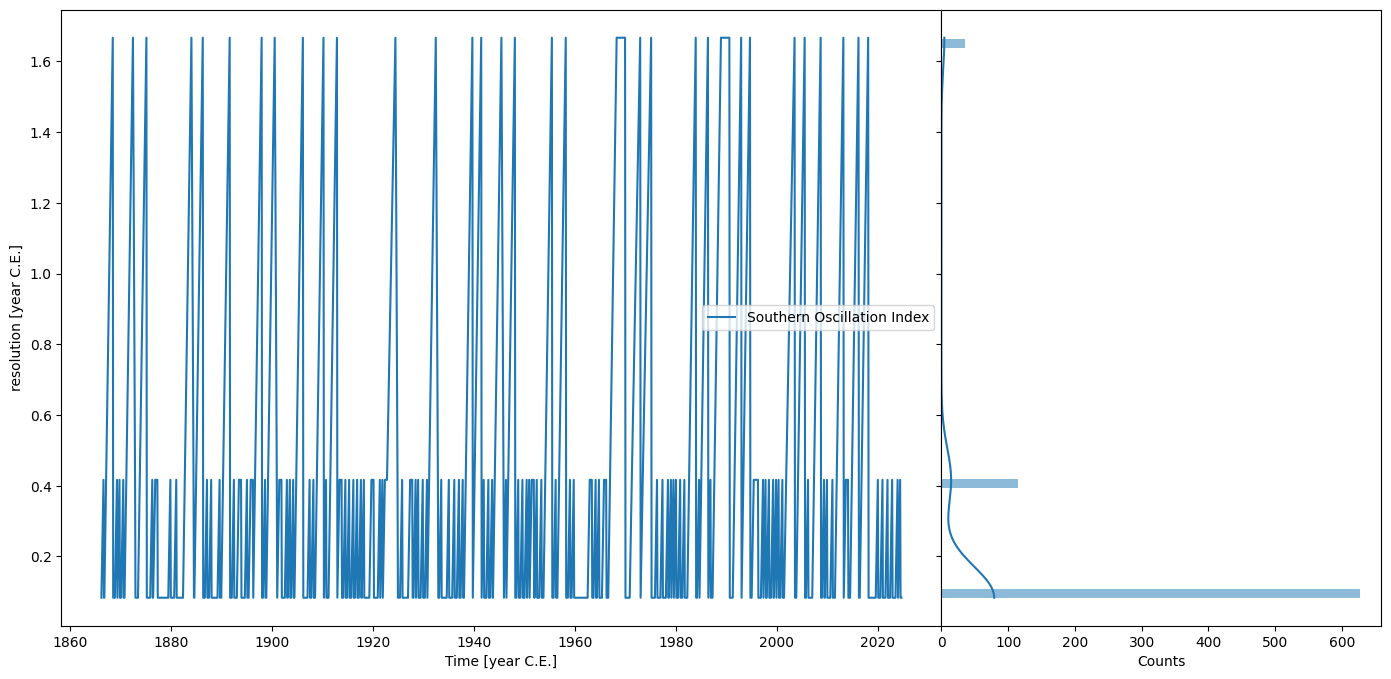

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [34]:
ds_rc.resolution().dashboard()

## Method comparison — gap-size histograms

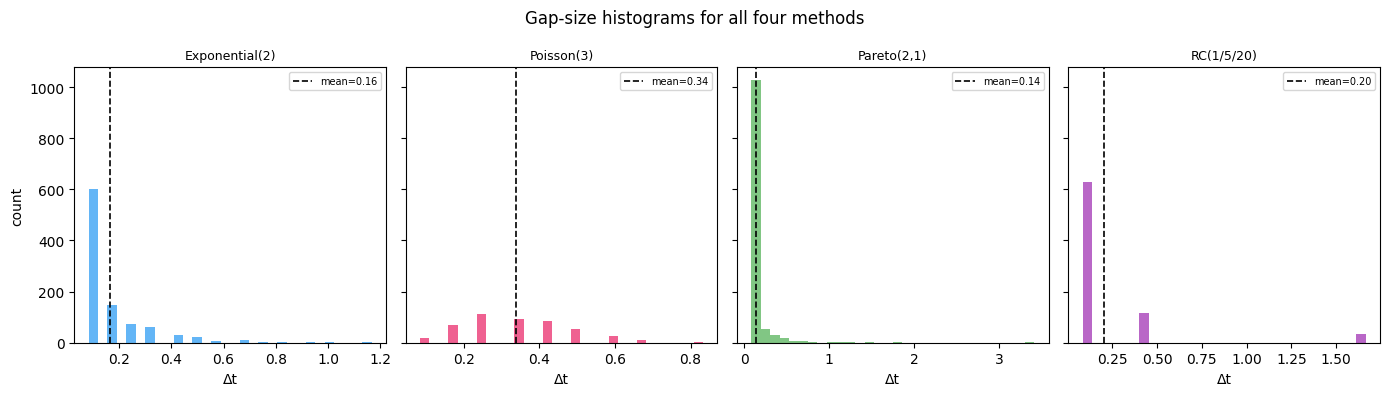

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}
{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


In [35]:
labels  = ['Exponential(2)', 'Poisson(3)', 'Pareto(2,1)', 'RC(1/5/20)']
dss     = [ds_exp, ds_poi, ds_par, ds_rc]
colours = ['#2196F3', '#E91E63', '#4CAF50', '#9C27B0']

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, ds, lbl, col in zip(axes, dss, labels, colours):
    gaps = np.diff(ds.time)
    ax.hist(gaps, bins=30, color=col, alpha=0.7, edgecolor='none')
    ax.axvline(gaps.mean(), color='k', lw=1.2, ls='--',
               label=f'mean={gaps.mean():.2f}')
    ax.set_title(lbl, fontsize=9); ax.set_xlabel('Δt'); ax.legend(fontsize=7)
axes[0].set_ylabel('count')
fig.suptitle('Gap-size histograms for all four methods')
plt.tight_layout(); plt.show()


**Figure.** Exponential: mode near zero, exponential decay. Poisson: symmetric
around the mean. Pareto: heavy right tail. Random choice: discrete spikes at
the specified values. Choose the distribution that matches your sampling process.
